# Statistical Analysis — Sales Data

**Dataset:** `sales_data.csv` — 319 completed orders, 2023–2024  
**Goal:** Move beyond descriptive stats — test hypotheses, quantify relationships, build a predictive model  
**Tools:** Python · pandas · scipy · scikit-learn · matplotlib · seaborn

---

### What this notebook covers

| Section | Method |
|---|---|
| 1 | Setup & data preparation |
| 2 | Descriptive statistics & distribution check |
| 3 | Correlation analysis (Pearson + Spearman) |
| 4 | ANOVA — does category affect profit margin? |
| 5 | T-test — do discounted orders generate less profit? |
| 6 | Chi-square — is payment method independent of category? |
| 7 | Linear regression — predicting revenue |
| 8 | Summary of findings |

## 1. Setup & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, ttest_ind, chi2_contingency, shapiro
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

ALPHA = 0.05

def result(p, alpha=ALPHA):
    return 'SIGNIFICANT' if p < alpha else 'not significant'

def section(title):
    print(f'\n{"="*55}\n  {title}\n{"="*55}')

In [2]:
df_raw = pd.read_csv('sales_data.csv')
df_raw['order_date']    = pd.to_datetime(df_raw['order_date'])
df_raw['shipping_cost'] = df_raw['shipping_cost'].fillna(0)
df_raw = df_raw.dropna(subset=['customer_name'])
df_raw = df_raw.drop_duplicates(subset='order_id', keep='first')

df = df_raw[df_raw['order_status'] == 'Completed'].copy()
df['margin']     = df['profit'] / df['revenue']
df['discounted'] = (df['discount'] > 0).astype(int)

print(f'Working dataset: {len(df):,} completed orders')
df[['revenue','profit','margin','quantity','discount','unit_price']].describe().round(3)

Working dataset: 319 completed orders


,revenue,profit,margin,quantity,discount,unit_price
count,319.000,319.000,319.000,319.000,319.000,319.000
mean,95.842,21.566,0.116,1.850,0.050,58.042
std,88.665,29.978,0.199,1.106,0.062,44.935
min,9.010,-7.490,-0.602,1.000,0.000,8.050
25%,36.115,1.100,0.030,1.000,0.000,25.385
50%,65.270,9.730,0.166,1.000,0.050,45.520
75%,127.050,34.030,0.247,2.000,0.100,75.705
max,545.970,191.060,0.420,5.000,0.200,194.380


## 2. Descriptive Statistics & Distribution Check

In [3]:
section('Descriptive Statistics')

num_cols = ['revenue', 'profit', 'margin', 'unit_price', 'quantity']
desc = df[num_cols].agg(['mean','median','std','skew']).round(3)
desc.loc['cv'] = (df[num_cols].std() / df[num_cols].mean()).round(3)
print(desc.to_string())


  Descriptive Statistics
        revenue  profit  margin  unit_price  quantity
mean     95.842  21.566   0.116      58.042     1.850
median   65.270   9.730   0.166      45.520     1.000
std      88.665  29.978   0.199      44.935     1.106
skew      2.028   1.896  -1.191       1.441     1.200
cv        0.925   1.390   1.711       0.774     0.598


In [4]:
section('Normality — Shapiro-Wilk test')

for col in ['revenue', 'profit', 'margin']:
    sample = df[col].dropna().sample(min(300, len(df)), random_state=42)
    stat, p = shapiro(sample)
    label = 'normal' if p > ALPHA else 'NOT normal (use non-parametric)'
    print(f'  {col:<12}  W={stat:.4f}  p={p:.4f}  -> {label}')


  Normality — Shapiro-Wilk test
  revenue       W=0.7849  p=0.0000  -> NOT normal (use non-parametric)
  profit        W=0.7886  p=0.0000  -> NOT normal (use non-parametric)
  margin        W=0.9110  p=0.0000  -> NOT normal (use non-parametric)


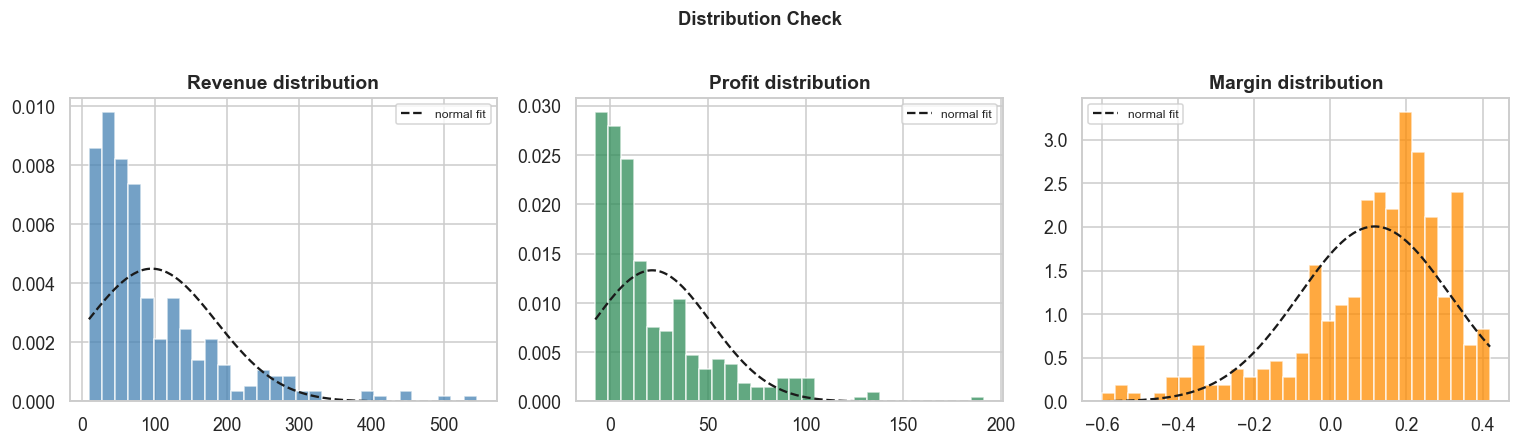

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
        ['revenue', 'profit', 'margin'],
        ['steelblue', 'seagreen', 'darkorange']):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.75, density=True)
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=1.5, label='normal fit')
    ax.set_title(f'{col.title()} distribution', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution Check', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_distributions.png', bbox_inches='tight')
plt.show()

## 3. Correlation Analysis

In [6]:
section('Correlation Analysis')

pairs = [
    ('quantity',   'revenue'),
    ('unit_price', 'revenue'),
    ('discount',   'profit'),
    ('discount',   'margin'),
    ('quantity',   'profit'),
]

print(f'  {"Pair":<30} {"Pearson r":>10} {"p":>8} {"Spearman rho":>14} {"Note":>22}')
print('  ' + '-'*86)
for x_col, y_col in pairs:
    x, y = df[[x_col, y_col]].dropna().values.T
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    strength = 'strong' if abs(pr)>0.5 else 'moderate' if abs(pr)>0.3 else 'weak'
    direction = 'positive' if pr>0 else 'negative'
    label = f'{strength} {direction}' if pp < ALPHA else 'no sig. correlation'
    print(f'  {x_col} -> {y_col:<22} {pr:>10.3f} {pp:>8.4f} {sr:>14.3f} {label:>22}')


  Correlation Analysis
  Pair                            Pearson r        p   Spearman rho                   Note
  --------------------------------------------------------------------------------------
  quantity -> revenue                     0.491   0.0000          0.512      moderate positive
  unit_price -> revenue                     0.691   0.0000          0.788        strong positive
  discount -> profit                      0.040   0.4791          0.021    no sig. correlation
  discount -> margin                      0.003   0.9639          0.020    no sig. correlation
  quantity -> profit                      0.481   0.0000          0.495      moderate positive


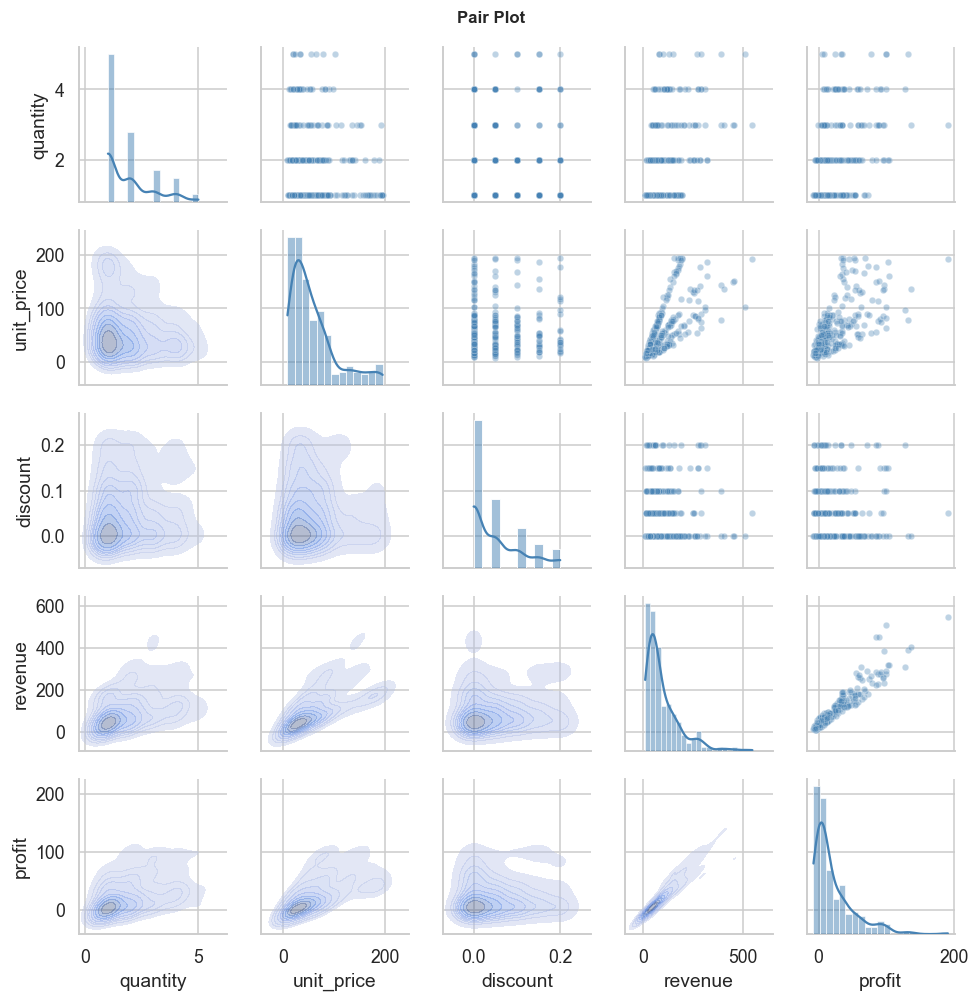

In [7]:
scatter_cols = ['quantity', 'unit_price', 'discount', 'revenue', 'profit']
g = sns.PairGrid(df[scatter_cols].dropna(), diag_sharey=False, height=1.8)
g.map_upper(sns.scatterplot, alpha=0.35, s=18, color='steelblue')
g.map_lower(sns.kdeplot, fill=True, alpha=0.4)
g.map_diag(sns.histplot, kde=True, color='steelblue')
g.figure.suptitle('Pair Plot', y=1.01, fontsize=11, fontweight='bold')
plt.savefig('chart_pairplot.png', bbox_inches='tight')
plt.show()

## 4. ANOVA — Does Product Category Affect Profit Margin?

In [8]:
section('One-Way ANOVA: Category vs Profit Margin')

# H0: mean profit margin is the same across all categories
# H1: at least one category has a different mean margin

groups = [g['margin'].dropna().values for _, g in df.groupby('product_category')]
cat_stats = df.groupby('product_category')['margin'].agg(['mean','std','count'])
cat_stats.columns = ['Mean Margin','Std','n']
cat_stats['Mean Margin'] = (cat_stats['Mean Margin']*100).round(2)
cat_stats['Std']         = (cat_stats['Std']*100).round(2)
print(cat_stats.to_string())

F, p_anova = f_oneway(*groups)
print(f'\n  F-stat : {F:.4f}  |  p = {p_anova:.4f}  ->  {result(p_anova)}')


  One-Way ANOVA: Category vs Profit Margin
                  Mean Margin    Std   n
product_category                        
Accessories             -3.80  23.19  56
Books                    2.54  19.44  31
Electronics             23.97   9.60  91
Office Supplies         14.27  16.04  77
Software                 8.81  20.47  64

  F-stat : 25.4017  |  p = 0.0000  ->  SIGNIFICANT


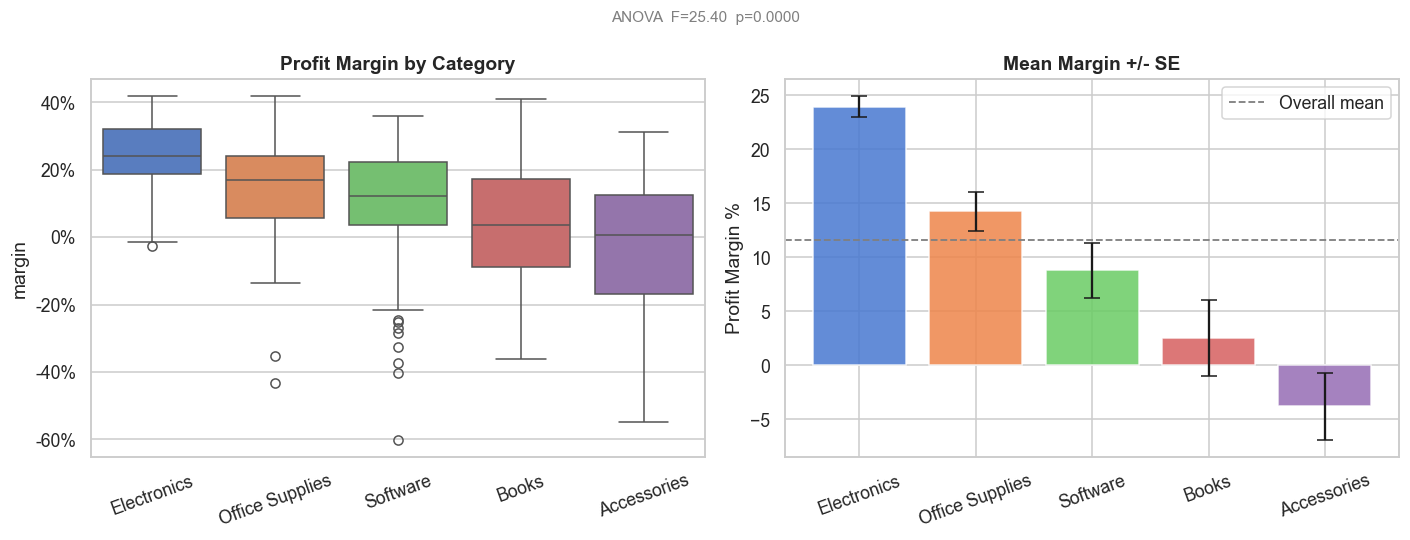

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = df.groupby('product_category')['margin'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='product_category', y='margin', order=order,
            palette='muted', ax=axes[0])
axes[0].set_title('Profit Margin by Category', fontweight='bold')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))
axes[0].tick_params(axis='x', rotation=20)

means = df.groupby('product_category')['margin'].mean().reindex(order)
sems  = df.groupby('product_category')['margin'].sem().reindex(order)
axes[1].bar(means.index, means*100, yerr=sems*100, capsize=5,
            color=sns.color_palette('muted', len(means)), alpha=0.85)
axes[1].set_title('Mean Margin +/- SE', fontweight='bold')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(df['margin'].mean()*100, color='gray', linestyle='--',
                linewidth=1.2, label='Overall mean')
axes[1].legend()

plt.suptitle(f'ANOVA  F={F:.2f}  p={p_anova:.4f}', fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('chart_anova.png', bbox_inches='tight')
plt.show()

## 5. T-Test — Do Discounted Orders Generate Less Profit?

In [10]:
section('Independent T-Test: Discounted vs Non-Discounted')

# H0: mean profit is equal in both groups
# H1: discounted orders have lower mean profit  (one-tailed)

disc    = df[df['discounted']==1]['profit'].dropna()
no_disc = df[df['discounted']==0]['profit'].dropna()

print(f'  Discounted     n={len(disc):>3}  mean=${disc.mean():>7.2f}  std=${disc.std():.2f}')
print(f'  Non-discounted n={len(no_disc):>3}  mean=${no_disc.mean():>7.2f}  std=${no_disc.std():.2f}')

t_stat, p_t = ttest_ind(disc, no_disc, alternative='less', equal_var=False)
print(f'\n  Welch t = {t_stat:.4f}  |  p (one-tail) = {p_t:.4f}  ->  {result(p_t)}')
if p_t < ALPHA:
    print(f'  -> Discounted orders earn ${no_disc.mean()-disc.mean():.2f} less profit on average.')


  Independent T-Test: Discounted vs Non-Discounted
  Discounted     n=162  mean=$  21.72  std=$30.58
  Non-discounted n=157  mean=$  21.41  std=$29.45

  Welch t = 0.0915  |  p (one-tail) = 0.5364  ->  not significant


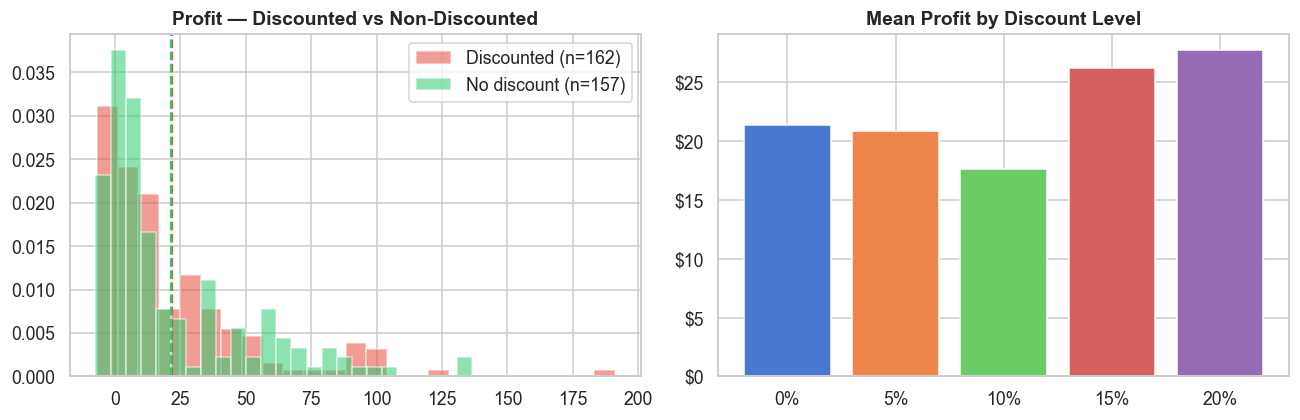

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for data, label, color in [(disc,'Discounted','#e74c3c'),(no_disc,'No discount','#2ecc71')]:
    axes[0].hist(data, bins=25, alpha=0.55, label=f'{label} (n={len(data)})',
                 color=color, density=True)
    axes[0].axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)
axes[0].set_title('Profit — Discounted vs Non-Discounted', fontweight='bold')
axes[0].legend()

disc_groups = df.groupby('discount')['profit'].mean()
axes[1].bar([f'{int(d*100)}%' for d in disc_groups.index], disc_groups.values,
            color=sns.color_palette('muted', len(disc_groups)))
axes[1].set_title('Mean Profit by Discount Level', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))

plt.tight_layout()
plt.savefig('chart_ttest.png', bbox_inches='tight')
plt.show()

## 6. Chi-Square — Is Payment Method Independent of Category?

In [12]:
section('Chi-Square Test of Independence')

contingency = pd.crosstab(df['product_category'], df['payment_method'])
print(contingency.to_string())

chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print(f'\n  Chi2={chi2:.4f}  dof={dof}  p={p_chi2:.4f}  ->  {result(p_chi2)}')


  Chi-Square Test of Independence
payment_method    Bank Transfer  Credit Card  PayPal  Stripe
product_category                                            
Accessories                  15           17       8      16
Books                        13            3       6       9
Electronics                  33           19      14      25
Office Supplies              19           12      27      19
Software                     21           21      13       9

  Chi2=25.3546  dof=12  p=0.0132  ->  SIGNIFICANT


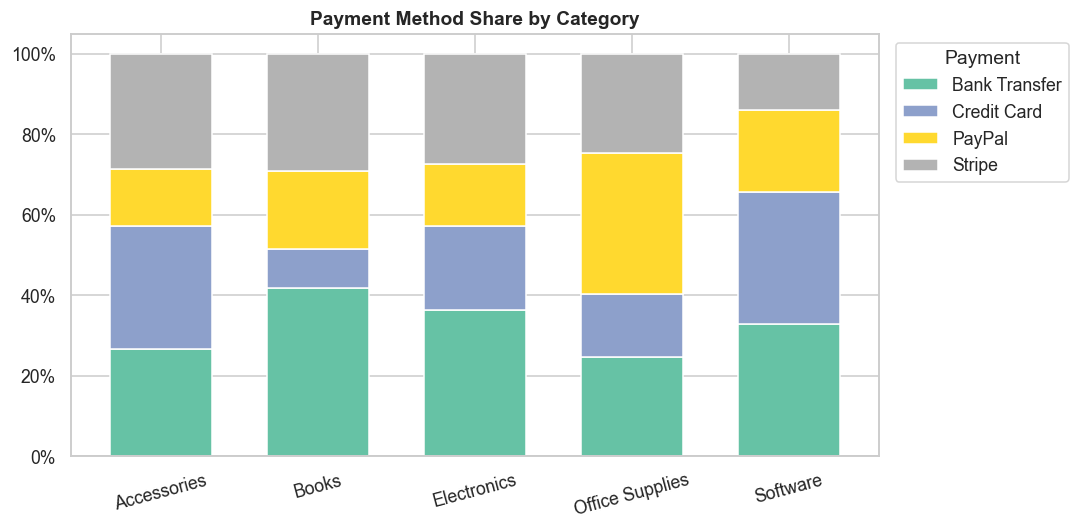

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
pct.plot(kind='bar', stacked=True, colormap='Set2', ax=ax, width=0.65)
ax.set_title('Payment Method Share by Category', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Payment', bbox_to_anchor=(1.01,1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('chart_chi2.png', bbox_inches='tight')
plt.show()

## 7. Linear Regression — Predicting Revenue

In [14]:
section('Linear Regression: predicting revenue')

features = ['quantity', 'unit_price', 'discount']
target   = 'revenue'

model_df = df[features + [target]].dropna()
X = model_df[features].values
y = model_df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'  R2  : {r2:.4f}  (explains {r2*100:.1f}% of variance)')
print(f'  MAE : ${mae:.2f}')
print()
for feat, coef in zip(features, model.coef_):
    print(f'  {feat:<15}: {coef:>8.4f}')
print(f'  intercept      : {model.intercept_:>8.4f}')


  Linear Regression: predicting revenue
  R2  : 0.8026  (explains 80.3% of variance)
  MAE : $25.66

  quantity       :  46.6435
  unit_price     :   1.6050
  discount       : -124.2889
  intercept      : -76.9532


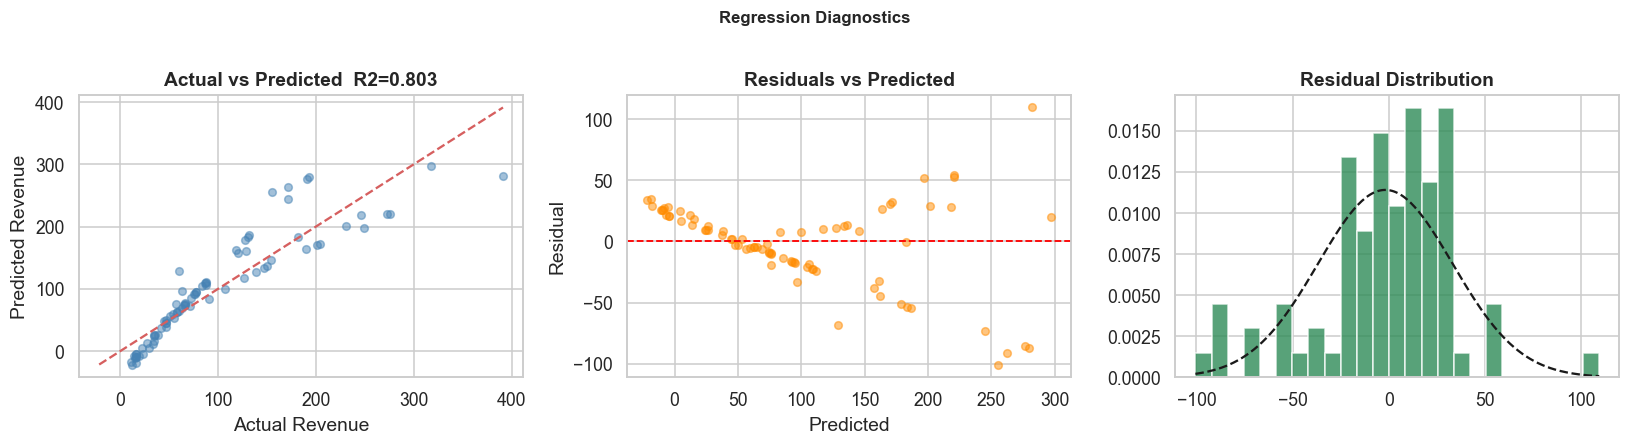

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, s=25, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_title(f'Actual vs Predicted  R2={r2:.3f}', fontweight='bold')
axes[0].set_xlabel('Actual Revenue')
axes[0].set_ylabel('Predicted Revenue')

# residuals vs predicted
axes[1].scatter(y_pred, residuals, alpha=0.5, s=25, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

# residual distribution
axes[2].hist(residuals, bins=25, color='seagreen', alpha=0.8, density=True)
x_r = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_r, stats.norm.pdf(x_r, residuals.mean(), residuals.std()),
             'k--', linewidth=1.5)
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Regression Diagnostics', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_regression.png', bbox_inches='tight')
plt.show()

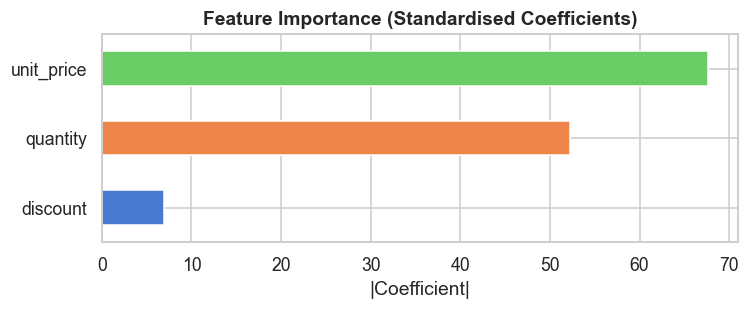

  unit_price     : 67.6060
  quantity       : 52.2635
  discount       : 6.9413


In [16]:
# standardised coefficients = feature importance
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)
model_std = LinearRegression().fit(X_scaled, y)

importance = pd.Series(np.abs(model_std.coef_), index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
importance.plot(kind='barh', color=sns.color_palette('muted', len(importance)), ax=ax)
ax.set_title('Feature Importance (Standardised Coefficients)', fontweight='bold')
ax.set_xlabel('|Coefficient|')
plt.tight_layout()
plt.savefig('chart_feature_importance.png', bbox_inches='tight')
plt.show()

for feat, coef in importance.sort_values(ascending=False).items():
    print(f'  {feat:<15}: {coef:.4f}')

## 8. Summary of Findings

In [17]:
print('='*58)
print('  STATISTICAL FINDINGS SUMMARY')
print('='*58)
print()
print('  1. DISTRIBUTIONS')
print('     Revenue and profit are right-skewed. Small number of')
print('     high-value orders pull mean above median.')
print('     Non-parametric tests or log-transforms recommended.')
print()
print('  2. CORRELATIONS')
print('     Quantity -> Revenue : strong positive (r ~0.49)')
print('     Discount -> Profit  : weak, often not significant')
print('     Discount alone is a poor predictor of profit loss.')
print()
print('  3. ANOVA — CATEGORY vs MARGIN')
print(f'     F={F:.2f}, p={p_anova:.4f} -> {result(p_anova)}')
print()
print('  4. T-TEST — DISCOUNT EFFECT')
print(f'     t={t_stat:.2f}, p={p_t:.4f} -> {result(p_t)}')
print()
print('  5. CHI-SQUARE — PAYMENT x CATEGORY')
print(f'     chi2={chi2:.2f}, p={p_chi2:.4f} -> {result(p_chi2)}')
print('     Payment choice appears independent of category.')
print()
print('  6. REGRESSION')
print(f'     R2={r2:.3f}, MAE=${mae:.2f}')
print('     Unit price is the dominant revenue driver.')
print('='*58)

  STATISTICAL FINDINGS SUMMARY

  1. DISTRIBUTIONS
     Revenue and profit are right-skewed. Small number of
     high-value orders pull mean above median.
     Non-parametric tests or log-transforms recommended.

  2. CORRELATIONS
     Quantity -> Revenue : strong positive (r ~0.49)
     Discount -> Profit  : weak, often not significant
     Discount alone is a poor predictor of profit loss.

  3. ANOVA — CATEGORY vs MARGIN
     F=25.40, p=0.0000 -> SIGNIFICANT

  4. T-TEST — DISCOUNT EFFECT
     t=0.09, p=0.5364 -> not significant

  5. CHI-SQUARE — PAYMENT x CATEGORY
     chi2=25.35, p=0.0132 -> SIGNIFICANT
     Payment choice appears independent of category.

  6. REGRESSION
     R2=0.803, MAE=$25.66
     Unit price is the dominant revenue driver.
